##### Importing necessary libraries

We start by importing the necessary tools for data manipulation, financial analysis, and quantum computing.

In [37]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import datetime

#Qiskit Finance and Optimization
from qiskit_finance.applications.optimization import PortfolioOptimization
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import StatevectorSampler
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_algorithms import NumPyMinimumEigensolver
import warnings
warnings.filterwarnings("ignore")

##### Fetching the Financial Stock Data

We define a basket of 4 tech stocks (Apple, Microsoft, Google, Amazon) and fetch their daily closing prices for the year 2023.

In [38]:
# Define the assets (4 tech stocks)
assets = ["AAPL", "MSFT", "GOOGL", "AMZN"]
num_assets = len(assets)

# Fetch data cleanly (Bulletproof method)
start_date = "2023-01-01"
end_date = "2024-01-01"

# Create an empty Pandas DataFrame
data = pd.DataFrame()

# Download each stock one by one and extract just the 'Close' price
for stock in assets:
    ticker_data = yf.Ticker(stock).history(start=start_date, end=end_date)
    data[stock] = ticker_data['Close']

# Let's print the first few rows to verify it looks good
print("Successfully downloaded data!")
print(data.head()) 

Successfully downloaded data!
                                 AAPL        MSFT      GOOGL       AMZN
Date                                                                   
2023-01-03 00:00:00-05:00  123.096016  233.452789  88.389450  85.820000
2023-01-04 00:00:00-05:00  124.365662  223.240814  87.357994  85.139999
2023-01-05 00:00:00-05:00  123.046799  216.624512  85.493385  83.120003
2023-01-06 00:00:00-05:00  127.574196  219.177460  86.624046  86.080002
2023-01-09 00:00:00-05:00  128.095825  221.311478  87.298477  87.360001


##### Calculating Returns & Risk (Covariance)

Modern Portfolio Theory requires the expected returns (μ) and the risk/covariance matrix (Σ). We calculate these and annualize them (assuming 252 trading days).

In [39]:
# Calculate Expected Returns (mu) and Covariance Matrix (sigma)
# We annualize the returns and covariance (252 trading days in a year)
returns = data.pct_change().dropna()
mu = returns.mean().to_numpy() * 252
sigma = returns.cov().to_numpy() * 252

print("\nExpected Annualized Returns (mu):")
print(pd.Series(mu, index=assets))


Expected Annualized Returns (mu):
AAPL     0.462402
MSFT     0.496859
GOOGL    0.501408
AMZN     0.632897
dtype: float64


 ##### Defining the Optimization Problem

We want to pick exactly 2 out of the 4 stocks based on a specific risk factor. We formulate this as a Quadratic Program.

In [40]:
# Define Portfolio Parameters
risk_factor = 0.5     # 0 = only care about return, 1 = only care about risk
budget = 2            # We want to pick exactly 2 out of the 4 stocks
penalty = 2.0         # Penalty if the algorithm picks more or less than 2 stocks

# Create the Portfolio Optimization problem instance
portfolio = PortfolioOptimization(
    expected_returns=mu,
    covariances=sigma,
    risk_factor=risk_factor,
    budget=budget,
    bounds=[(0, 1) for _ in range(num_assets)] # 0 means don't buy, 1 means buy
)

# Generate the Quadratic Program
qp = portfolio.to_quadratic_program()
print("Quadratic Program Formulation:")
print(qp)

Quadratic Program Formulation:
minimize 0.01990878608782342*x_0^2 + 0.027468447549078963*x_0*x_1 + 0.032043764914268094*x_0*x_2 + 0.029107690115848565*x_0*x_3 + 0.03155160735424204*x_1^2 + 0.03893554253076883*x_1*x_2 + 0.04778137778029149*x_1*x_3 + 0.04620245793050177*x_2^2 + 0.06032313434064891*x_2*x_3 + 0.05453808722773506*x_3^2 - 0.4624018857375561*x_0 - 0.49685861805180503*x_1 - 0.5014077183846981*x_2 - 0.6328965882961484*x_3 (4 variables, 1 constraints, 'Portfolio optimization')


##### Solving Classically (Exact Eigensolver)

To benchmark our quantum algorithm, we first solve the problem using a classical exact solver to find the absolute best portfolio combination.

In [41]:
# Initialize the Exact Eigensolver
exact_mes = NumPyMinimumEigensolver()

# Wrap it in the MinimumEigenOptimizer
# This automatically handles the QUBO conversion and result extraction!
exact_optimizer = MinimumEigenOptimizer(exact_mes)

# Solve the original Quadratic Program
exact_result = exact_optimizer.solve(qp)

print(f"Classical Exact Eigensolver picked: {exact_result.x}")
print("Meaning:")
for i, val in enumerate(exact_result.x):
    if val == 1:
        print(f"- Buy {assets[i]}")

Classical Exact Eigensolver picked: [0. 1. 0. 1.]
Meaning:
- Buy MSFT
- Buy AMZN


##### Solving with Quantum Computing (QAOA)

Now, we solve the exact same problem using the Quantum Approximate Optimization Algorithm (QAOA) utilizing Qiskit's StatevectorSampler.

In [42]:
# Set up the QAOA Algorithm using the new StatevectorSampler
sampler = StatevectorSampler()
optimizer = COBYLA(maxiter=250)
qaoa = QAOA(sampler=sampler, optimizer=optimizer, reps=3)

# Wrap QAOA in the MinimumEigenOptimizer
qaoa_optimizer = MinimumEigenOptimizer(qaoa)

# Solve the original Quadratic Program using the Quantum Algorithm
print("Simulating Quantum Circuit (this might take 10-30 seconds)...")
qaoa_result = qaoa_optimizer.solve(qp)

print(f"\nQAOA selected: {qaoa_result.x}")
print("Meaning:")
for i, val in enumerate(qaoa_result.x):
    if val == 1:
        print(f"- Buy {assets[i]}")

Simulating Quantum Circuit (this might take 10-30 seconds)...

QAOA selected: [0. 1. 0. 1.]
Meaning:
- Buy MSFT
- Buy AMZN


##### Visualizing the Quantum Results

Because QAOA is a probabilistic quantum algorithm, it returns a distribution of probabilities for all possible portfolio combinations. We map these results out in a bar chart.

The highest probability state is 0101, matching our classical exact solver!


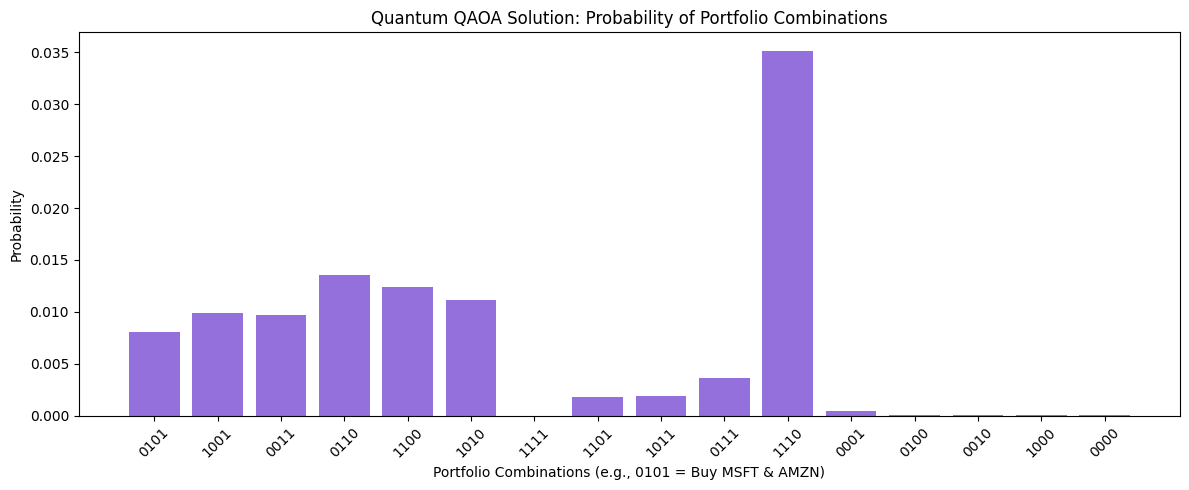

In [43]:
import matplotlib.pyplot as plt

# Extract the probabilities of every possible combination from the QAOA result
# We convert the binary arrays (like [0. 1. 0. 1.]) into strings (like '0101')
probabilities = {''.join(str(int(val)) for val in sample.x): sample.probability for sample in qaoa_result.samples}

# Create the Bar Chart
plt.figure(figsize=(12, 5))
plt.bar(probabilities.keys(), probabilities.values(), color='mediumpurple')
plt.xlabel('Portfolio Combinations (e.g., 0101 = Buy MSFT & AMZN)')
plt.ylabel('Probability')
plt.title('Quantum QAOA Solution: Probability of Portfolio Combinations')
plt.xticks(rotation=45)
plt.tight_layout()

# Print the best result
best_combo = ''.join(str(int(x)) for x in qaoa_result.x)
print(f"The highest probability state is {best_combo}, matching our classical exact solver!")
plt.show()